**This notebook was entirely AI GENERATED by GLM 5.2 using opencode (prompted by GN)**

# Domain closeness

Given a variant and a threshold (in %), count how many entries have their **second closest domain within `threshold%` of the closest**.

Source data: the domain neighbours file produced by `tools/classify.py`, which stores for each domain the top-10000 entries and their similarity scores:

`data/semantic_search/<VARIANT>/semantic_search-edition_7-doc2vec-learn-mc_40-ng_1-tm_0.5-ch_sentence.tv2_domains.json`

An entry absent from a domain's list has a score of 0 for that domain (see `helpers/classifiers/semantic_search.py`, `classify`). The metric is **relative**: an entry is counted when `closest > 0` and `second >= closest * (1 - threshold/100)`.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd

sys.path.append(str(Path.cwd().parent))
from helpers import settings

VARIANT = '2026-07-18'
THRESHOLD = 5
EDITION = 7

DOMAIN_NEIGHBOURS_FILENAME = 'semantic_search-edition_7-doc2vec-learn-mc_40-ng_1-tm_0.5-ch_sentence.tv2_domains.json'

domain_neighbours_path = Path(settings.DATA_PATH, 'semantic_search', VARIANT, DOMAIN_NEIGHBOURS_FILENAME)
if not domain_neighbours_path.exists():
    raise FileNotFoundError(f'No domain neighbours file found for variant "{VARIANT}" at {domain_neighbours_path}')

domain_results = json.loads(domain_neighbours_path.read_text())

print(f'Variant: {VARIANT}')
print(f'Threshold: {THRESHOLD}%')
print(f'Domains: {list(domain_results.keys())}')
print(f'Entries per domain list: {[len(r["aids"]) for r in domain_results.values()]}')

Variant: 2026-07-18
Threshold: 5%
Domains: ['sacred_history', 'civil_history', 'natural_history', 'useful_arts', 'theology', 'philosophy', 'natural_science', 'fine_arts']
Entries per domain list: [10000, 10000, 10000, 10000, 10000, 10000, 10000, 10000]


## Build the entry x domain score map

Each domain records its top-10000 entries with their similarity scores. An entry that does not appear in a domain's list has an implicit score of 0 for that domain. We gather, for every entry that appears in at least one list, its non-zero score per domain.

In [2]:
entry_scores = {}
for domain, results in domain_results.items():
    for aid, score in zip(results['aids'], results['scores']):
        entry_scores.setdefault(aid, {})[domain] = score

print(f'Entries present in at least one domain list: {len(entry_scores)}')

Entries present in at least one domain list: 20526


## Compute closest vs second closest domain

For each entry we sort its domain scores descending. `closest` is the highest score, `second` the next one (0 if the entry appears in only one domain list). An entry is **within the threshold** when `closest > 0` and `second >= closest * (1 - threshold/100)`.

In [3]:
rows = []
factor = 1 - THRESHOLD / 100
for aid, scores in entry_scores.items():
    ordered = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)
    closest_domain, closest_score = ordered[0]
    second_domain, second_score = ordered[1] if len(ordered) > 1 else (None, 0.0)
    ratio = second_score / closest_score if closest_score > 0 else 0.0
    within_threshold = closest_score > 0 and second_score >= closest_score * factor
    rows.append({
        'aid': aid,
        'closest_domain': closest_domain,
        'closest_score': closest_score,
        'second_domain': second_domain,
        'second_score': second_score,
        'ratio': ratio,
        'within_threshold': within_threshold,
    })

df = pd.DataFrame(rows).set_index('aid')
df.head()

,closest_domain,closest_score,second_domain,second_score,ratio,within_threshold
aid,,,,,,
eb07/XML/s19/kp-eb0719-060202-0656.xml,sacred_history,0.715666,theology,0.258049,0.360572,False
eb07/XML/h11/kp-eb0711-012101-0668.xml,sacred_history,0.507566,philosophy,0.318685,0.627869,False
eb07/XML/h11/kp-eb0711-050804-5699.xml,sacred_history,0.468648,theology,0.190556,0.406608,False
eb07/XML/p18/kp-eb0718-051803-9109.xml,sacred_history,0.457517,philosophy,0.231958,0.506994,False
eb07/XML/m15/kp-eb0715-000407-9261.xml,sacred_history,0.457250,theology,0.329615,0.720863,False


## Result

Number and percentage of entries whose second closest domain is within the threshold of the closest.

In [4]:
total = len(df)
count = int(df['within_threshold'].sum())
percentage = count / total * 100 if total else 0

print(f'{count} of {total} entries ({percentage:.1f}%) have their second closest domain within {THRESHOLD}% of the closest')

2154 of 20526 entries (10.5%) have their second closest domain within 5% of the closest


## Enrich with entry titles

Load the variant index (edition 7 only) and merge titles to inspect the flagged entries.

In [5]:
index_path = Path(settings.DATA_PATH, VARIANT, 'index.json')
df_index = pd.read_json(index_path, orient='table')
df_index = df_index[df_index['edition'] == EDITION]

print(f'{len(df_index)} entries in the index')
print(f'{len(df_index) - total} not in the domain neighbours file') 
print(f'{len(df_index[df_index["semantic_search-label"].isna()])} without a domain in the index [expects 0]')
print(f'{len(df_index[df_index["semantic_search-score"] == 0.0])} with a 0.000 score')

df_index.head(5)


21118 entries in the index
592 not in the domain neighbours file
0 without a domain in the index [expects 0]
592 with a 0.000 score


,edition,volume,page,title,labels,refs,vocd,msttr,mtld,chars,words,semantic_search-label,semantic_search-score,in_x
eb07/XML/k12/kp-eb0712-068604-6720.xml,7,12,686,"KELIKDONI, or Erminak","[Rivers, Fall, Swimming, Bladder, Rivers, Mino...","[lcsh1910:b4wh2dg8p, lcsh1910:b4cz32806, lcsh1...",0.000000,0.96000,269.080000,202.0,31.0,natural_history,0.282103,NaN
eb07/XML/k12/kp-eb0712-069001-6772.xml,7,12,690,KEMPEN,"[Linen, Towns, Linen]","[fasttopic:999105, lcsh1910:b4hq3s746, lcsh191...",0.000000,0.76000,38.760344,272.0,46.0,useful_arts,0.206429,NaN
eb07/XML/k12/kp-eb0712-075805-7656.xml,7,12,758,KOORANKOO,"[Africa, Niger, England, Towns, Sea, Wood, Art...","[fastgeo:1239509, fastgeo:1205480, fastgeo:121...",73.342269,0.86087,81.615409,10254.0,1741.0,natural_history,0.152690,NaN
eb07/XML/k12/kp-eb0712-067405-6564.xml,7,12,674,KANDERN,"[Towns, Iron, Work, Iron, Work]","[lcsh1910:b4hq3s746, lcsh1910:b4n00zz70, lcsh1...",20.910494,0.66000,17.872892,337.0,55.0,useful_arts,0.304589,NaN
eb07/XML/k12/kp-eb0712-068501-6707.xml,7,12,685,KEFIL,"[Arabis, Jews, Tombs, Resorts, Jews, Tombs, Re...","[fasttopic:812568, fasttopic:983135, fasttopic...",0.000000,0.84000,60.480000,204.0,36.0,sacred_history,0.341369,NaN


In [6]:
df_titles = df_index[['title']]

flagged = df[df['within_threshold']].join(df_titles, how='inner')
flagged = flagged[['title', 'closest_domain', 'closest_score', 'second_domain', 'second_score', 'ratio']]
flagged.sort_values('ratio', ascending=False).head(20)

,title,closest_domain,closest_score,second_domain,second_score,ratio
eb07/XML/a3/kp-eb0703-028001-9201.xml,AONIDES,sacred_history,0.252714,fine_arts,0.252698,0.999935
eb07/XML/m14/kp-eb0714-023301-2851.xml,"MANICORDON, or Maniciiord",useful_arts,0.155521,fine_arts,0.155506,0.999899
eb07/XML/m15/kp-eb0715-059702-6970.xml,"MURDER, or Murtiier",philosophy,0.150160,sacred_history,0.150143,0.999890
eb07/XML/m14/kp-eb0714-000101-9835.xml,"MAGNETISM, ANIMAL",natural_science,0.216629,theology,0.216595,0.999847
eb07/XML/e9/kp-eb0709-005604-5986.xml,ENIGMA,sacred_history,0.170804,civil_history,0.170778,0.999844
eb07/XML/p18/kp-eb0718-013809-4117.xml,PODSPUSKNOI,useful_arts,0.190461,natural_history,0.190430,0.999840
eb07/XML/v21/kp-eb0721-064301-0683.xml,"VIDA, Marco GeroNIMO",civil_history,0.148053,fine_arts,0.148017,0.999756
eb07/XML/v21/kp-eb0721-070302-0743.xml,"VOSSIUS, Gerard John",sacred_history,0.160351,civil_history,0.160311,0.999750
eb07/XML/j12/kp-eb0712-058601-5420.xml,JIGAT Point,useful_arts,0.152275,theology,0.152234,0.999728
eb07/XML/v21/kp-eb0721-060506-0643.xml,VERTICITY,natural_science,0.225921,philosophy,0.225855,0.999708


In [7]:
flagged.sort_values('closest_score', ascending=False).head(10)

,title,closest_domain,closest_score,second_domain,second_score,ratio
eb07/XML/e8/kp-eb0708-056402-0467.xml,ELCESAITES,sacred_history,0.451961,theology,0.432816,0.957640
eb07/XML/j12/kp-eb0712-062501-5927.xml,JUDAISM,sacred_history,0.423542,theology,0.413107,0.975364
eb07/XML/h12/kp-eb0712-013706-9583.xml,HYPERDULIA,sacred_history,0.416081,theology,0.407302,0.978900
eb07/XML/r19/kp-eb0719-022904-0239.xml,RHYTHM,philosophy,0.391224,fine_arts,0.386828,0.988763
eb07/XML/p18/kp-eb0718-052701-9226.xml,PRESCIENCE,philosophy,0.383184,theology,0.368647,0.962064
eb07/XML/a2/kp-eb0702-038812-4853.xml,"ALCORAN, or Al-koran",theology,0.382438,sacred_history,0.363917,0.951573
eb07/XML/a3/kp-eb0703-024807-8785.xml,ANTHROPOLATRAE,philosophy,0.380543,sacred_history,0.362441,0.952431
eb07/XML/c7/kp-eb0707-020901-9989.xml,CONDORMIENTES,theology,0.377641,sacred_history,0.368628,0.976134
eb07/XML/f10/kp-eb0710-024007-7087.xml,FRY,natural_history,0.374824,natural_science,0.371495,0.991117
eb07/XML/t21/kp-eb0721-023604-0254.xml,THEORY,philosophy,0.372891,natural_science,0.371797,0.997067


## Breakdown by closest domain

How the flagged entries distribute across their closest domain.

In [8]:
breakdown = flagged.groupby('closest_domain').size().sort_values(ascending=False)
breakdown

closest_domain
sacred_history     358
natural_history    344
useful_arts        319
philosophy         274
natural_science    268
civil_history      215
theology           199
fine_arts          177
dtype: int64

## Distribution of second/closest ratios

Histogram of the ratio of the second closest score over the closest score, with the threshold line at `1 - threshold/100`.

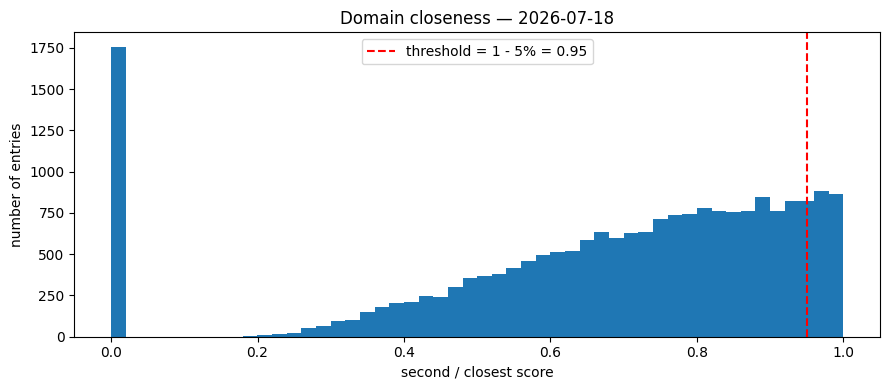

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['ratio'], bins=50)
ax.axvline(factor, color='red', linestyle='--', label=f'threshold = 1 - {THRESHOLD}% = {factor:.2f}')
ax.set_xlabel('second / closest score')
ax.set_ylabel('number of entries')
ax.set_title(f'Domain closeness — {VARIANT}')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
without_second_domain = len(df[df['second_score'] == 0.0])
print(f'{without_second_domain} entries are within the 10k nearest neighbours of one domain only (see blue bar on the left of the chart)')

1757 entries are within the 10k nearest neighbours of one domain only (see blue bar on the left of the chart)
